In [2]:
import os
import sys
import json
import torch
import pandas as pd
import numpy as np
from tqdm import tqdm

sys.path.append(os.path.abspath(".."))
from transformer_architecture_base import Decoder

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(torch.__version__)
print(DEVICE)

2.5.1
cuda


In [3]:
df = pd.read_csv("../data/preprocessed_data.csv")
df.head()

,City_id,Seq_id,Year,Month,Lat,Lon,Population_Density_per_SqKm,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),...,O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT
0,Canberra | Australia,24169,2014,1,-35.2931,149.1269,343.71,6.85,21.13,3.37,...,38.00,1.07,2.41,2.54,39.0,12.88,47.47,0.0051,0.77,7.80
1,Sydney | Australia,24169,2014,1,-33.8678,151.2100,3734.49,14.88,8.24,2.46,...,60.70,0.62,2.35,0.78,84.0,25.59,71.72,0.0055,0.69,7.42
2,Newcastle | Australia,24169,2014,1,-32.9167,151.7500,371.91,5.57,18.62,2.57,...,60.82,0.80,1.97,1.38,27.0,26.06,57.64,0.0042,1.17,12.21
3,Wollongong | Australia,24169,2014,1,-34.4331,150.8831,5.00,4.98,19.61,2.52,...,45.29,1.39,5.07,1.44,35.0,9.97,50.29,0.0025,1.16,4.09
4,Central Coast | Australia,24169,2014,1,-33.2992,151.1922,5.00,4.94,9.70,4.26,...,46.39,1.12,3.01,2.51,41.0,8.34,45.25,0.0041,1.33,5.44


In [4]:
with open("../data/entity_seq_pair.json", 'r') as f:
    ds = json.load(f)
ds_test = ds["test"]
ds_test_only = ds["test_entities"]


In [5]:
SEQ_LEN = 30
VAL_TIME = 12
TEST_TIME = 12
TEST_ONLY_ENITY = 45

In [6]:
BATCH_SIZE = 384
EPOCHS = 5
LEARNING_RATE = 1e-4

HIDDEN_DIM = 256

### Data Loader

In [ ]:
from torch.utils.data import DataLoader

/root/miniconda3/envs/torch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
test_loader = DataLoader(ds_test, batch_size = BATCH_SIZE)
test_only_loader = DataLoader(ds_test_only, batch_size = BATCH_SIZE)

In [9]:
df.columns

Index(['City_id', 'Seq_id', 'Year', 'Month', 'Lat', 'Lon',
       'Population_Density_per_SqKm', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)',
       'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'CO (mg/m3)',
       'SO2 (ug/m3)', 'O3 (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)',
       'Xylene (ug/m3)', 'AQI', 'Wind_Speed (km/h)', 'Humidity (%)',
       'Deforestation_Rate_%', 'Industry_Growth_%', 'CO2_Emission_MT'],
      dtype='object')

In [10]:
df = df.set_index(["City_id", "Seq_id"])
df.head()

,,Year,Month,Lat,Lon,Population_Density_per_SqKm,PM2.5 (ug/m3),PM10 (ug/m3),NO (ug/m3),NO2 (ug/m3),NOx (ppb),...,O3 (ug/m3),Benzene (ug/m3),Toluene (ug/m3),Xylene (ug/m3),AQI,Wind_Speed (km/h),Humidity (%),Deforestation_Rate_%,Industry_Growth_%,CO2_Emission_MT
City_id,Seq_id,,,,,,,,,,,,,,,,,,,,,
Canberra | Australia,24169,2014,1,-35.2931,149.1269,343.71,6.85,21.13,3.37,7.16,10.53,...,38.00,1.07,2.41,2.54,39.0,12.88,47.47,0.0051,0.77,7.80
Sydney | Australia,24169,2014,1,-33.8678,151.2100,3734.49,14.88,8.24,2.46,7.41,9.87,...,60.70,0.62,2.35,0.78,84.0,25.59,71.72,0.0055,0.69,7.42
Newcastle | Australia,24169,2014,1,-32.9167,151.7500,371.91,5.57,18.62,2.57,5.44,8.01,...,60.82,0.80,1.97,1.38,27.0,26.06,57.64,0.0042,1.17,12.21
Wollongong | Australia,24169,2014,1,-34.4331,150.8831,5.00,4.98,19.61,2.52,7.41,9.93,...,45.29,1.39,5.07,1.44,35.0,9.97,50.29,0.0025,1.16,4.09
Central Coast | Australia,24169,2014,1,-33.2992,151.1922,5.00,4.94,9.70,4.26,12.23,16.49,...,46.39,1.12,3.01,2.51,41.0,8.34,45.25,0.0041,1.33,5.44


In [11]:
col_count = len(df.columns)

model = Decoder(
    hidden_dim=HIDDEN_DIM,
    seq_len=SEQ_LEN,
    corpus_size=col_count - 4,
    n_heads=4,
    n_blocks=6,
    dropout=0.15,
    use_embedding=False,
    embedding_replacement=torch.nn.Linear(col_count, HIDDEN_DIM)
).to(DEVICE)
checkpoint = "latest"
model.load_state_dict(torch.load(f"../model/{checkpoint}.pth", map_location="cpu", weights_only=True))
model.to(DEVICE)

criterion = torch.nn.SmoothL1Loss()

print("Device:", next(model.parameters()).device)
print("Parameter Count:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Allocated Memory:", torch.cuda.memory_allocated() / 1024**3, "GB")
print("Reserved memory:", torch.cuda.memory_reserved() / 1024**3, "GB")

Device: cuda:0
Parameter Count: 6,339,347
Allocated Memory: 0.023616313934326172 GB
Reserved memory: 0.025390625 GB


# Training Loop

In [79]:
def load_tensor(entities, seq, seq_len=SEQ_LEN):
    regional_data = [] 

    for entity, sid in zip(entities, seq):
        sid = int(sid)
        entity = entity.item() if hasattr(entity, "item") else entity

        regional_data.append(torch.tensor(df.loc[entity].loc[sid:sid + seq_len].to_numpy()))


    regional_data = torch.stack(regional_data).to(DEVICE, torch.float32)
    return regional_data

In [13]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
with torch.no_grad():
    for entities, years in tqdm(test_loader, desc=f"Test"):
        regional_data = load_tensor(entities, years)
        pred = model(regional_data[:, :-1])
        ground_truth = regional_data[:, -1, 4:]
        pred = pred[:, -1]
    

        loss = criterion(pred, ground_truth)
        test_loss += loss.item()

        test_se += ((pred - ground_truth)**2).sum().item()
        test_count += pred.shape[0]

print(f"Test Loss: {test_loss/len(test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")


Test: 100%|██████████| 55/55 [00:12<00:00,  4.56it/s]

Test Loss: 69.94736973155628, RMSE = 371.12880615881807


In [14]:
model.eval()
test_loss = 0
test_se = 0
test_count = 0
with torch.no_grad():
    for entities, years in tqdm(test_only_loader, desc=f"Test"):
        regional_data = load_tensor(entities, years)
        pred = model(regional_data[:, :-1])
        ground_truth = regional_data[:, -1, 4:]
        pred = pred[:, -1]
    

        loss = criterion(pred, ground_truth)
        test_loss += loss.item()

        test_se += ((pred - ground_truth)**2).sum().item()
        test_count += pred.shape[0]

print(f"Test Loss: {test_loss/len(test_loader)}, RMSE = {(test_se/(test_count*col_count))**0.5}")


Test: 100%|██████████| 14/14 [00:03<00:00,  4.30it/s]

Test Loss: 16.917374697598543, RMSE = 283.22189902703866


In [ ]:
used_data = ds_test_only[0]

['Albany | Australia', 24169]

In [ ]:
pred_test = sorted(
    [x for x in ds_test_only if x[0] == used_data[0]],
    key=lambda x: x[1]
)
len(pred_test)

114

In [64]:
result = []

with torch.no_grad():
    for entities, years in tqdm(pred_test, desc=f"Test"):
        regional_data = load_tensor([entities], [years])
        pred = model(regional_data[:, :-1])
        ground_truth = regional_data[:, -1, 4:]
        pred = pred[:, -1]
        result.append(pred)

result = torch.stack(result).squeeze(1)
result.shape

Test: 100%|██████████| 114/114 [00:01<00:00, 62.10it/s]


torch.Size([114, 19])

In [113]:
from joblib import load

scaler = load("../model/scaler.pkl")

# Convert to NumPy
data = result.detach().cpu().numpy()

# Append 4 dummy columns
filler = np.zeros((data.shape[0], 4))
data = np.concatenate([filler, data], axis=1)

# Inverse transform
data = scaler.inverse_transform(data)

data = data[:, 4:]
data.shape

(114, 19)

In [114]:
all_seq_len = pred_test[-1][1] - pred_test[0][1] + SEQ_LEN

In [ ]:
ground_truth = load_tensor([pred_test[0][0]], [pred_test[0][1]], seq_len=all_seq_len)
ground_truth = ground_truth.squeeze(0).detach().cpu().numpy*()
ground_truth = scaler.inverse_transform(ground_truth)
ground_truth = ground_truth[:, 4:]
ground_truth.shape

(144, 19)

In [116]:
import matplotlib.pyplot as plt

In [117]:
data_range = np.arange(SEQ_LEN, all_seq_len+1, 1)
gt_range = np.arange(0, all_seq_len+1, 1)

In [118]:
colnames = df.columns[4:]

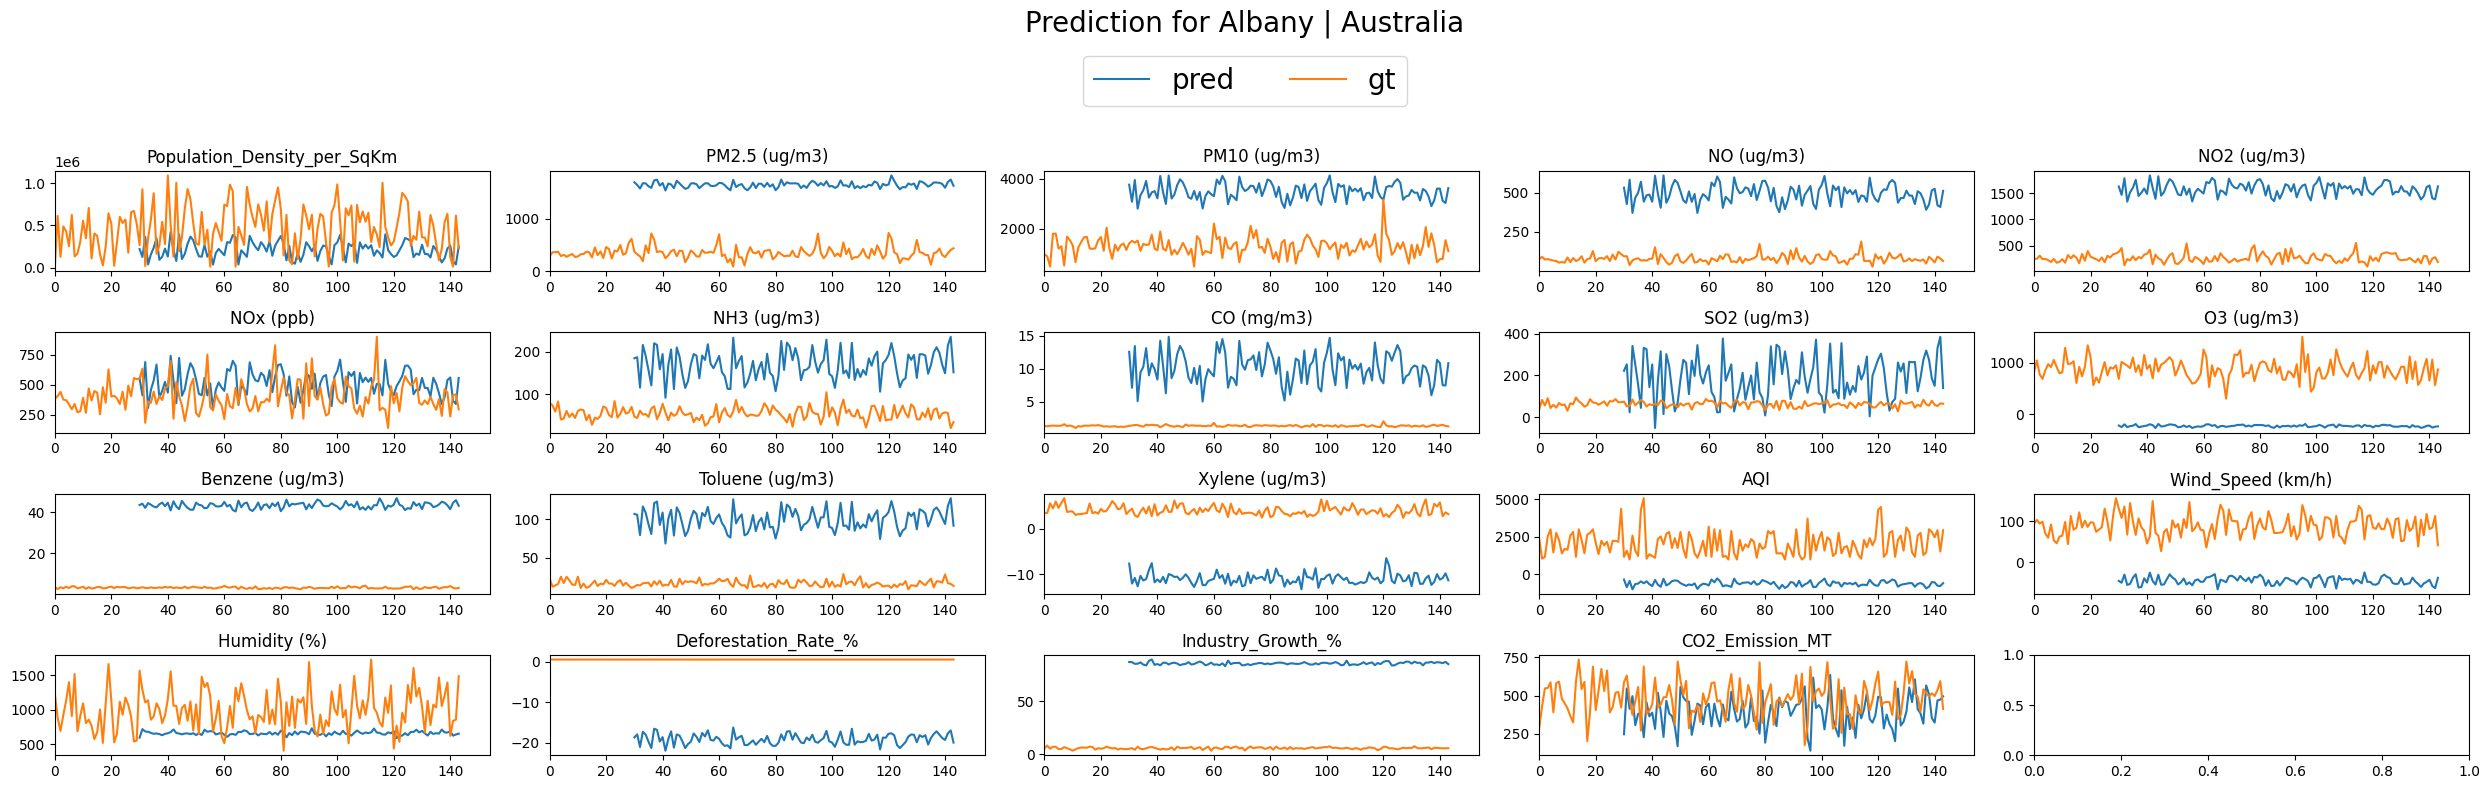

In [144]:
fig, ax = plt.subplots(4, 5, figsize=(25, 8))

for i in range(19):
    ax[i//5, i%5].plot(data_range, data[:, i], label = "pred")
    ax[i//5, i%5].plot(gt_range, ground_truth[:, i], label = "gt")
    ax[i//5, i%5].set_title(colnames[i])
    ax[i//5, i%5].set_xlim(0, all_seq_len+11)

handles, labels = ax[0, 0].get_legend_handles_labels()

# Create a figure-level legend
fig.suptitle(f"Prediction for {pred_test[0][0]}", fontsize=20)
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=20, bbox_to_anchor=(0.5, 0.94),)

plt.tight_layout(rect=[0, 0, 1, 0.88])  # Leave space for the legend
plt.show()